In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('data/titanic3.csv')
data.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [3]:
data.shape

(1309, 14)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


Para la siguiente informacion se tomara 0 como no y 1 como si

In [5]:
data['survived'].value_counts()

survived
0    809
1    500
Name: count, dtype: int64

<Axes: xlabel='survived'>

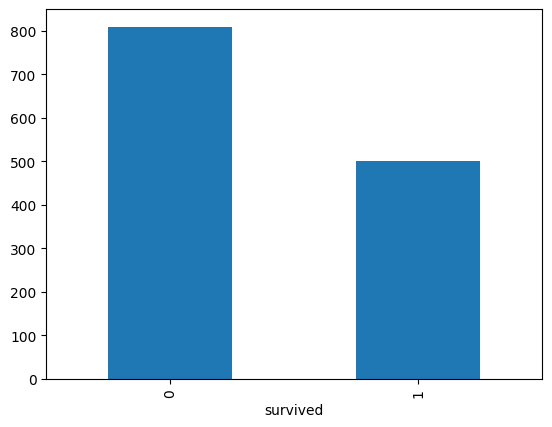

In [6]:
data['survived'].value_counts().plot(kind='bar')

In [7]:
data['sex'].value_counts()

sex
male      843
female    466
Name: count, dtype: int64

<Axes: xlabel='sex'>

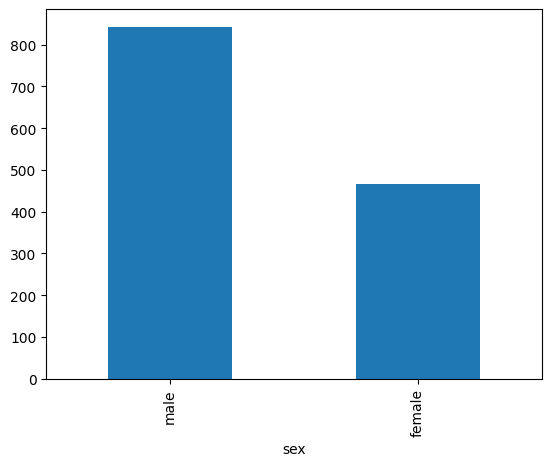

In [8]:
data['sex'].value_counts().plot(kind='bar')

In [9]:
data[['sex', 'survived']].groupby('sex').mean()

,survived
sex,
female,0.727468
male,0.190985


In [10]:
data['pclass'].value_counts()

pclass
3    709
1    323
2    277
Name: count, dtype: int64

In [11]:
data[['pclass', 'survived']].groupby('pclass').mean()

,survived
pclass,
1,0.619195
2,0.429603
3,0.255289


In [12]:
data.groupby('pclass')['sex'].value_counts().sort_values(ascending=False)

pclass  sex   
3       male      493
        female    216
1       male      179
2       male      171
1       female    144
2       female    106
Name: count, dtype: int64

In [13]:
data[['sibsp', 'survived']].groupby('sibsp').mean().sort_values(by = 'survived', ascending=False)

,survived
sibsp,
1,0.510972
2,0.452381
0,0.346801
3,0.300000
4,0.136364
5,0.000000
8,0.000000


In [14]:
data[['parch', 'survived']].groupby('parch').mean().sort_values(by = 'survived', ascending=False)

,survived
parch,
3,0.625000
1,0.588235
2,0.504425
0,0.335329
4,0.166667
5,0.166667
6,0.000000
9,0.000000


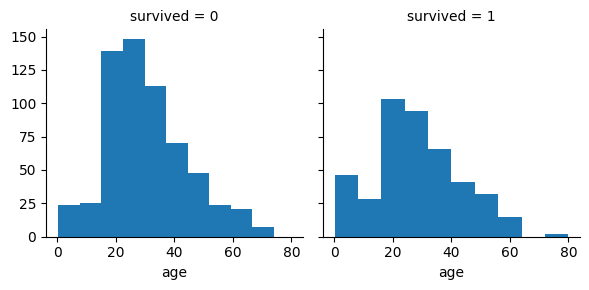

In [15]:
hist_agr = sns.FacetGrid(data, col='survived')
hist_agr.map(plt.hist, 'age', bins=10)

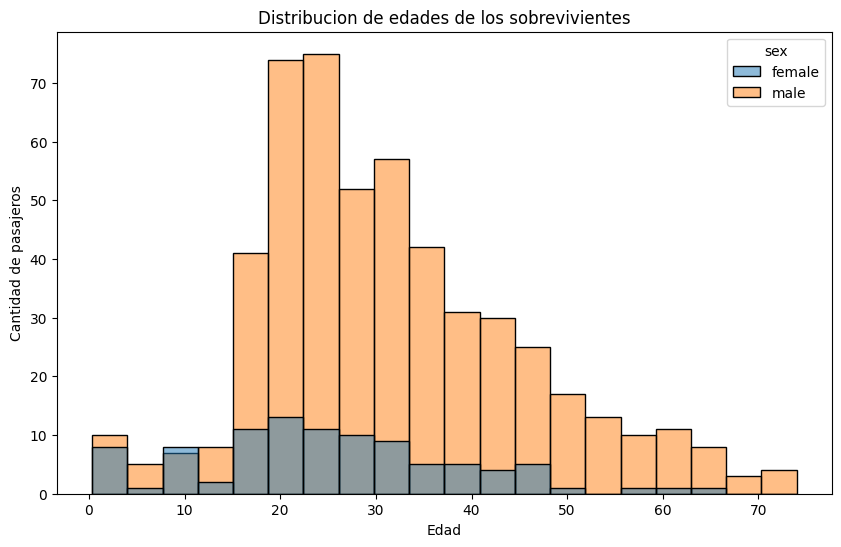

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data= data[data['survived'] == 0], x='age', hue='sex', bins=20, label='No sobrevivio')
plt.xlabel('Edad')
plt.ylabel('Cantidad de pasajeros')
plt.title('Distribucion de edades de los no sobrevivientes')
plt.show()

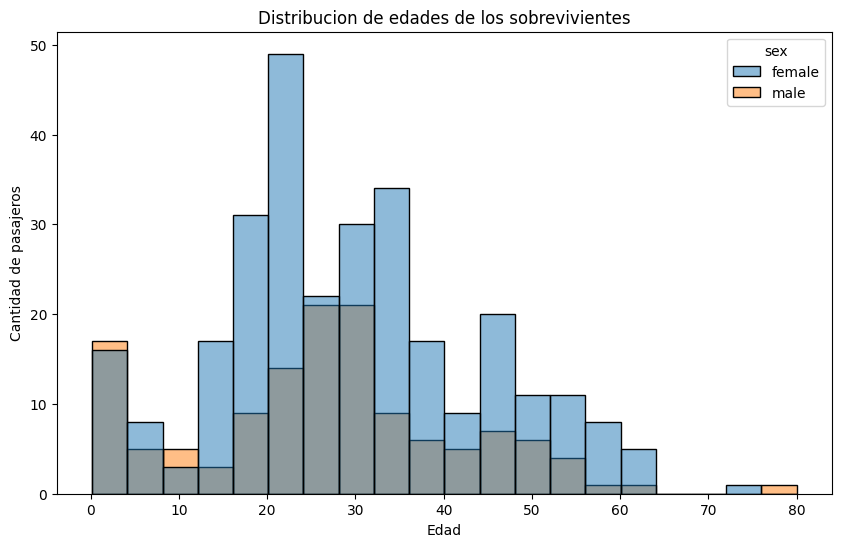

In [26]:
plt.figure(figsize=(10,6))
sns.histplot(data= data[data['survived'] == 1], x='age', hue='sex', bins=20, label='sobrevivientes')
plt.xlabel('Edad')
plt.ylabel('Cantidad de pasajeros')
plt.title('Distribucion de edades de los sobrevivientes')
plt.show()

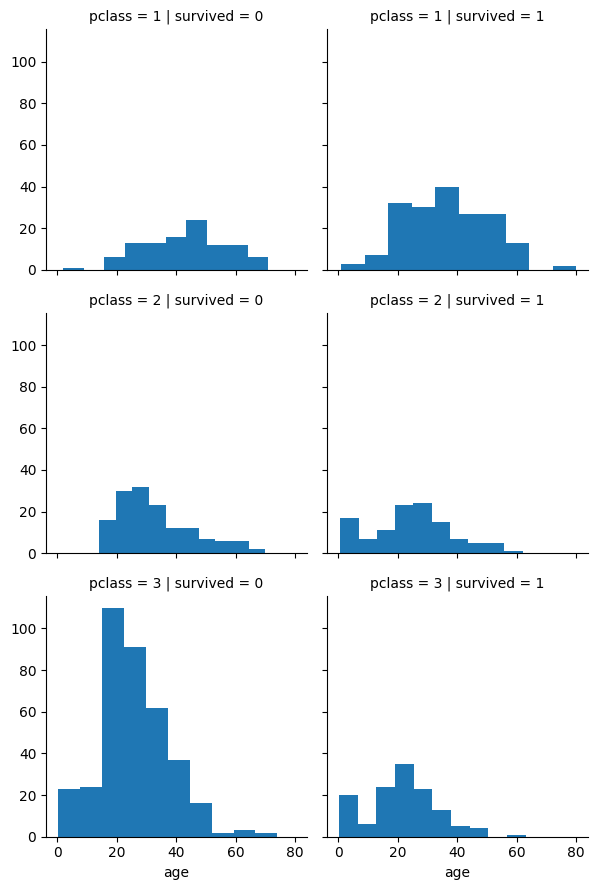

In [27]:
grid = sns.FacetGrid(data, col='survived', row='pclass')
grid.map(plt.hist, 'age', bins=10)
grid.add_legend()